# 05 · 评测与消融对比

> 对应 JD 关键词：**模型评测、对比实验**。沿用你 T5 项目的"消融对比表 + BLEU"，升级加入 **LLM-as-judge**。

## 三档对比
| 档位 | 模型 |
|---|---|
| base | 原始 Qwen2.5（没微调） |
| +SFT | 03 的 sft_merged |
| +SFT+DPO | 04 的 dpo_merged |

> 开放式问答里答案表述多样，单条 BLEU 偏低很正常；**看三档之间的相对变化**才是重点。

In [1]:
import os, json, sys   # os=文件/路径操作, json=读写json数据, sys=系统相关
import torch           # PyTorch：深度学习框架(模型和张量都靠它)

# 自动找到项目根目录（notebooks 文件夹的上一级）
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
DATA = os.path.join(ROOT, "data")      # data 目录完整路径
OUT  = os.path.join(ROOT, "outputs")   # outputs 目录完整路径
os.makedirs(OUT, exist_ok=True)        # 新建 outputs 目录；exist_ok=True=已存在也不报错

# 选计算设备：苹果芯片用 mps，英伟达显卡用 cuda，都没有就用 cpu
DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT  :", ROOT)
print("DEVICE:", DEVICE)

ROOT  : /Users/yunye/Documents/工作/项目/llm_sft_dpo_legalqa
DEVICE: mps


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODELS = {                                # 字典 {名字: 模型路径}
    "base":      os.path.join(ROOT, "models", "Qwen2.5-0.5B-Instruct"),  # 改本地路径，避开联网下载
    "+SFT":      os.path.join(OUT, "sft_merged"),
    "+SFT+DPO":  os.path.join(OUT, "dpo_merged"),
}
def generate(model, tokenizer, system, user, max_new_tokens=256):   # 同03,注释见03
    msgs = [{"role":"system","content":system},{"role":"user","content":user}]
    text = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

In [3]:
# 评测集 = 02 留出的 sft_eval（保证和训练不重叠）
sft_eval = json.load(open(os.path.join(DATA, "sft_eval.json"), encoding="utf-8"))
# 列表推导式：从每条的 messages 里取出 system/user/标准答案
eval_items = [{"system": m["messages"][0]["content"],
               "user":   m["messages"][1]["content"],
               "ref":    m["messages"][2]["content"]} for m in sft_eval]
print("评测条数:", len(eval_items))

评测条数: 40


In [4]:
# ---- 三档模型轮流答题，收集预测 ----
preds = {name: [] for name in MODELS}    # 字典推导式：每个模型名→一个空列表
for name, path in MODELS.items():        # .items() 同时拿 键(name) 和 值(path)
    tok = AutoTokenizer.from_pretrained(path)
    mdl = AutoModelForCausalLM.from_pretrained(path, torch_dtype=torch.float32).to(DEVICE)
    for it in eval_items:
        preds[name].append(generate(mdl, tok, it["system"], it["user"]))
    del mdl                               # 删模型释放内存(三个轮流跑)
    print(name, "done")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

base done


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

+SFT done


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

+SFT+DPO done


In [5]:
# ---- 字符级 BLEU：衡量生成与标准答案的相似度(0~1)，无需额外装库 ----
import math
from collections import Counter          # Counter=计数器,统计每个元素出现几次

def char_ngrams(s, n):                    # 把字符串切成"连续n个字"的片段并计数
    s = list(s.replace(" ", ""))          # 去空格→单字列表
    return Counter(tuple(s[i:i+n]) for i in range(len(s)-n+1)) if len(s) >= n else Counter()

def bleu_char(ref, hyp, max_n=4):
    scores = []
    for n in range(1, max_n+1):           # 看1/2/3/4字片段重合度
        r, h = char_ngrams(ref, n), char_ngrams(hyp, n)
        overlap = sum((r & h).values())   # r&h=两计数器交集; .values()取次数; sum求和
        scores.append(overlap / max(1, sum(h.values())))   # 命中率(max防除0)
    gm = 0.0 if min(scores) == 0 else math.exp(sum(math.log(x) for x in scores)/len(scores))  # 几何平均
    rl, hl = len(ref), max(1, len(hyp))
    bp = 1.0 if hl >= rl else math.exp(1 - rl/hl)   # 长度惩罚:太短扣分
    return bp * gm

def judge_rule(ref, hyp):                 # 规则版"AI裁判"(粗略),0~1
    if not hyp.strip():
        return 0.0
    score = 0.6                           # 基础分
    if "9999" in hyp or "三倍惩罚性赔偿" in hyp:
        score -= 0.4                      # 出现我们注入的编造法条(幻觉)→扣
    if len(hyp) < 20:
        score -= 0.3                      # 太短/截断→扣
    # 关键词覆盖：标准答案里的高频法律词，生成里命中越多越好(粗略衡量"答到点子上")
    keys = [w for w in ["法律","合同","责任","赔偿","权利","义务","规定","当事人","法院","民法典"] if w in ref]
    hit  = sum(1 for w in keys if w in hyp)
    if keys:
        score += 0.4 * (hit / len(keys))  # 命中比例×0.4
    return max(0.0, min(1.0, score))      # 夹到0~1

In [6]:
import statistics as st
rows = []
for name in MODELS:
    # zip(a,b)=两个列表配对,每次同时取(题目it,预测p)
    bleus  = [bleu_char(it["ref"], p) for it, p in zip(eval_items, preds[name])]
    judges = [judge_rule(it["ref"], p) for it, p in zip(eval_items, preds[name])]
    rows.append((name, st.mean(bleus), st.mean(judges)))

# 拼成 markdown 表格(=简历要引用的消融对比表)
lines = ["| 模型 | 字符BLEU | LLM-judge |", "|---|---|---|"]
for name, b, j in rows:
    lines.append("| %s | %.3f | %.3f |" % (name, b, j))
table = "\n".join(lines)                 # "\n".join(列表)=用换行连成整段
print(table)
open(os.path.join(OUT, "ablation_table.md"), "w", encoding="utf-8").write(table + "\n")

| 模型 | 字符BLEU | LLM-judge |
|---|---|---|
| base | 0.051 | 0.787 |
| +SFT | 0.058 | 0.779 |
| +SFT+DPO | 0.065 | 0.752 |


121

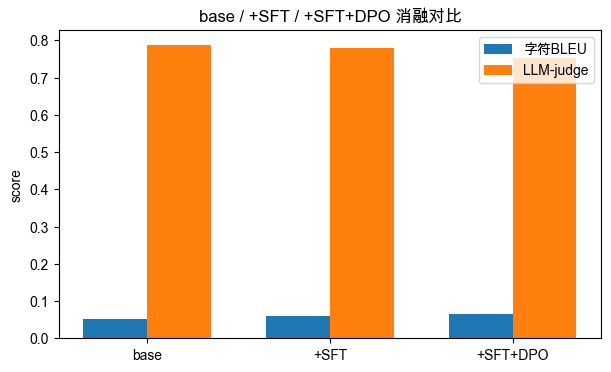

In [7]:
# ---- 消融柱状图 ----
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["Arial Unicode MS", "PingFang SC", "Heiti SC"]
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
names=[r[0] for r in rows]; bl=[r[1] for r in rows]; jg=[r[2] for r in rows]
x=range(len(names)); w=0.35
plt.figure(figsize=(7,4))
plt.bar([i-w/2 for i in x], bl, w, label="字符BLEU")
plt.bar([i+w/2 for i in x], jg, w, label="LLM-judge")
plt.xticks(list(x), names); plt.ylabel("score"); plt.title("base / +SFT / +SFT+DPO 消融对比"); plt.legend()
os.makedirs(os.path.join(OUT, "figures"), exist_ok=True)
plt.savefig(os.path.join(OUT, "figures", "ablation.png"), dpi=120, bbox_inches="tight"); plt.show()

In [8]:
# ---- badcase：base 答得差、SFT+DPO 修好的例子 ----
os.makedirs(os.path.join(OUT, "eval"), exist_ok=True)
bad = []
for i, it in enumerate(eval_items):      # enumerate=同时给下标i和元素it
    b = bleu_char(it["ref"], preds["base"][i])
    d = bleu_char(it["ref"], preds["+SFT+DPO"][i])
    if d - b > 0.05:                     # 最终比base明显好→记为被修好的case
        bad.append({"问题": it["user"], "base": preds["base"][i][:120],
                    "SFT+DPO": preds["+SFT+DPO"][i][:120]})
json.dump(bad, open(os.path.join(OUT, "eval", "badcases.json"), "w", encoding="utf-8"), ensure_ascii=False, indent=2)
print("被修好的 case 数:", len(bad))
for c in bad[:2]:
    print("Q:", c["问题"]); print("base   :", c["base"]); print("SFT+DPO:", c["SFT+DPO"]); print("-"*50)

被修好的 case 数: 12
Q: 啥样算重婚罪的具体行为？
base   : 根据《刑法》第三百九十二条的规定，重婚是指有配偶者与他人结婚的行为。因此，重婚罪的具体行为包括：（一）有配偶者与他人同居；（二）明知他人有配偶而与之结婚；（三）有配偶者与他人结婚未登记而与他人结婚；（四）明知他人有配偶而与之结婚。
SFT+DPO: 根据《中华人民共和国刑法》第三百一十三条的规定，重婚是指有配偶者与他人结婚的行为。重婚是婚姻登记机关审查当事人是否符合结婚条件所必须具备的条件之一。重婚的，处二年以下有期徒刑或者拘役。重婚的，由公安机关处十日以上十五日以下拘留，并处五百元以
--------------------------------------------------
Q: 婚前买房离婚属于共同财产吗?
base   : 根据《中华人民共和国民法典》第一千零六十二条的规定，夫妻在婚姻关系存续期间所得的下列财产，为夫妻的共同财产，归夫妻共同所有：（一）工资、奖金、劳务报酬；（二）生产、经营的收益；（三）知识产权的收益；（四）继承或者受赠的财产，但是本法第一千零
SFT+DPO: 婚前房产在婚姻关系存续期间取得的，不属于夫妻一方的个人财产。但是，在婚姻关系存续期间，所得的财产归夫妻双方共同所有。所以婚前房产在婚姻关系存续期间取得的，属于夫妻共同财产。离婚时，如婚前房产为夫妻双方共同财产，则应由双方协商分割，协商不成的
--------------------------------------------------
